In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import sys
sys.path.append("../")

DATA_DIR = "../mu3e_trigger_data"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_with_layer_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_with_layer_mppc_spacetime.npy"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_with_layer_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_with_layer_mppc_spacetime.npy"



In [2]:
bg_pixel_data = np.load(BACKGROUND_PIXEL_FILE)
sig_pixel_data = np.load(SIGNAL_PIXEL_FILE)
from src.utils import get_spacetime_data
bg_pixel_data = get_spacetime_data(bg_pixel_data)
sig_pixel_data = get_spacetime_data(sig_pixel_data)
print(f"Background pixel data shape: {bg_pixel_data.shape}")
print(f"Signal pixel data shape: {sig_pixel_data.shape}")

Background pixel data shape: (189252, 256, 4)
Signal pixel data shape: (177028, 256, 4)


In [3]:
import torch
from src.torch.model.components import get_mlp

class AutoEncoder(torch.nn.Module):
    def __init__(self, input_shape, bottleneck_size, num_layers = 3):
        super(AutoEncoder, self).__init__()
        if isinstance(input_shape, int):
            input_size = input_shape
        elif isinstance(input_shape, tuple):
            input_size = np.prod(input_shape)
        else:
            raise ValueError("input_shape must be an int or a tuple")
        self.encoder = get_mlp(input_size, bottleneck_size, num_layers=num_layers)
        self.decoder = get_mlp(bottleneck_size, input_size, num_layers=num_layers)
        self.input_shape = input_shape

    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        x_recon = self.decoder(z)
        x_recon = x_recon.view(x.size(0), *self.input_shape)
        return x_recon
        
class VarAutoEncoder(torch.nn.Module):
    def __init__(self, input_shape, bottleneck_size, num_layers = 3):
        super(VarAutoEncoder, self).__init__()
        if isinstance(input_shape, int):
            input_size = input_shape
        elif isinstance(input_shape, tuple):
            input_size = np.prod(input_shape)
        else:
            raise ValueError("input_shape must be an int or a tuple")
        self.encoder = get_mlp(input_size, bottleneck_size*2, num_layers=num_layers)
        self.decoder = get_mlp(bottleneck_size, input_size, num_layers=num_layers)
        self.input_shape = input_shape

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.encoder(x)
        mu, logvar = torch.chunk(h, 2, dim=1)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        x_recon = x_recon.view(x.size(0), *self.input_shape)
        return x_recon, mu, logvar


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(bg_pixel_data, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
del bg_pixel_data

In [5]:
autoencoder = AutoEncoder(input_shape=X_train.shape[1:], bottleneck_size=16, num_layers=5)
print(f"AutoEncoder has {sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)} trainable parameters")

AutoEncoder has 1126370 trainable parameters


In [6]:
loss = torch.nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
from torch.utils.data import DataLoader, TensorDataset
train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, X_val), batch_size=64, shuffle=False)
from tqdm import tqdm
num_epochs = 20
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    autoencoder.train()
    train_loss = 0
    for x, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        optimizer.zero_grad()
        x_recon = autoencoder(x)
        l = loss(x_recon, x)
        l.backward()
        optimizer.step()
        train_loss += l.item() * x.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for x, _ in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            x_recon = autoencoder(x)
            l = loss(x_recon, x)
            val_loss += l.item() * x.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

Epoch 1/20 - Validation: 100%|██████████| 592/592 [00:00<00:00, 1986.61it/s]


Epoch 1/20, Train Loss: 433.952249, Val Loss: 401.089383


Epoch 2/20 - Validation: 100%|██████████| 592/592 [00:00<00:00, 1639.24it/s]


Epoch 2/20, Train Loss: 388.098311, Val Loss: 377.456417


Epoch 3/20 - Validation: 100%|██████████| 592/592 [00:00<00:00, 1918.21it/s]


...

Epoch 18/20, Train Loss: 340.399080, Val Loss: 341.459385


Epoch 19/20 - Validation: 100%|██████████| 592/592 [00:00<00:00, 2020.93it/s]


Epoch 19/20, Train Loss: 340.114215, Val Loss: 341.176232


Epoch 20/20 - Validation: 100%|██████████| 592/592 [00:00<00:00, 2021.20it/s]

Epoch 20/20, Train Loss: 339.864404, Val Loss: 341.491955


In [7]:
from torch.nn import KLDivLoss, MSELoss
kld_loss = KLDivLoss(reduction='batchmean')
mse_loss = MSELoss()
var_autoencoder = VarAutoEncoder(input_shape=X_train.shape[1:], bottleneck_size=16, num_layers=5)
print(f"VarAutoEncoder has {sum(p.numel() for p in var_autoencoder.parameters() if p.requires_grad)} trainable parameters")
optimizer = torch.optim.Adam(var_autoencoder.parameters(), lr=1e-3)
num_epochs = 20
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    var_autoencoder.train()
    train_loss = 0
    for x, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        optimizer.zero_grad()
        x_recon, mu, logvar = var_autoencoder(x)
        recon_loss = mse_loss(x_recon, x)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
        l = recon_loss + kl_loss
        l.backward()
        optimizer.step()
        train_loss += l.item() * x.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    var_autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for x, _ in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            x_recon, mu, logvar = var_autoencoder(x)
            recon_loss = mse_loss(x_recon, x)
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
            l = recon_loss + kl_loss
            val_loss += l.item() * x.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

VarAutoEncoder has 1262247 trainable parameters


Epoch 1/20 - Validation: 100%|██████████| 592/592 [00:00<00:00, 1389.84it/s]


Epoch 1/20, Train Loss: 483.931942, Val Loss: 465.938438


Epoch 2/20 - Validation: 100%|██████████| 592/592 [00:00<00:00, 1458.73it/s]


Epoch 2/20, Train Loss: 463.582765, Val Loss: 459.410860


...

Epoch 18/20, Train Loss: 446.617994, Val Loss: 445.934607


Epoch 19/20 - Validation: 100%|██████████| 592/592 [00:00<00:00, 1626.41it/s]


Epoch 19/20, Train Loss: 447.068637, Val Loss: 455.122703


Epoch 20/20 - Validation: 100%|██████████| 592/592 [00:00<00:00, 1655.99it/s]

Epoch 20/20, Train Loss: 447.922464, Val Loss: 446.667034


In [8]:
bg_x, bg_mu, bg_logvar = var_autoencoder(X_val)
sig_x, sig_mu, sig_logvar = var_autoencoder(torch.tensor(sig_pixel_data, dtype=torch.float32))

(<Figure size 1400x1000 with 16 Axes>,
 array([[<Axes: xlabel='$\\sigma$ 1', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 2', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 3', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 4', ylabel='Density'>],
        [<Axes: xlabel='$\\sigma$ 5', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 6', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 7', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 8', ylabel='Density'>],
        [<Axes: xlabel='$\\sigma$ 9', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 10', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 11', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 12', ylabel='Density'>],
        [<Axes: xlabel='$\\sigma$ 13', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 14', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 15', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 16', ylabel='Density'>]], dtype=object))

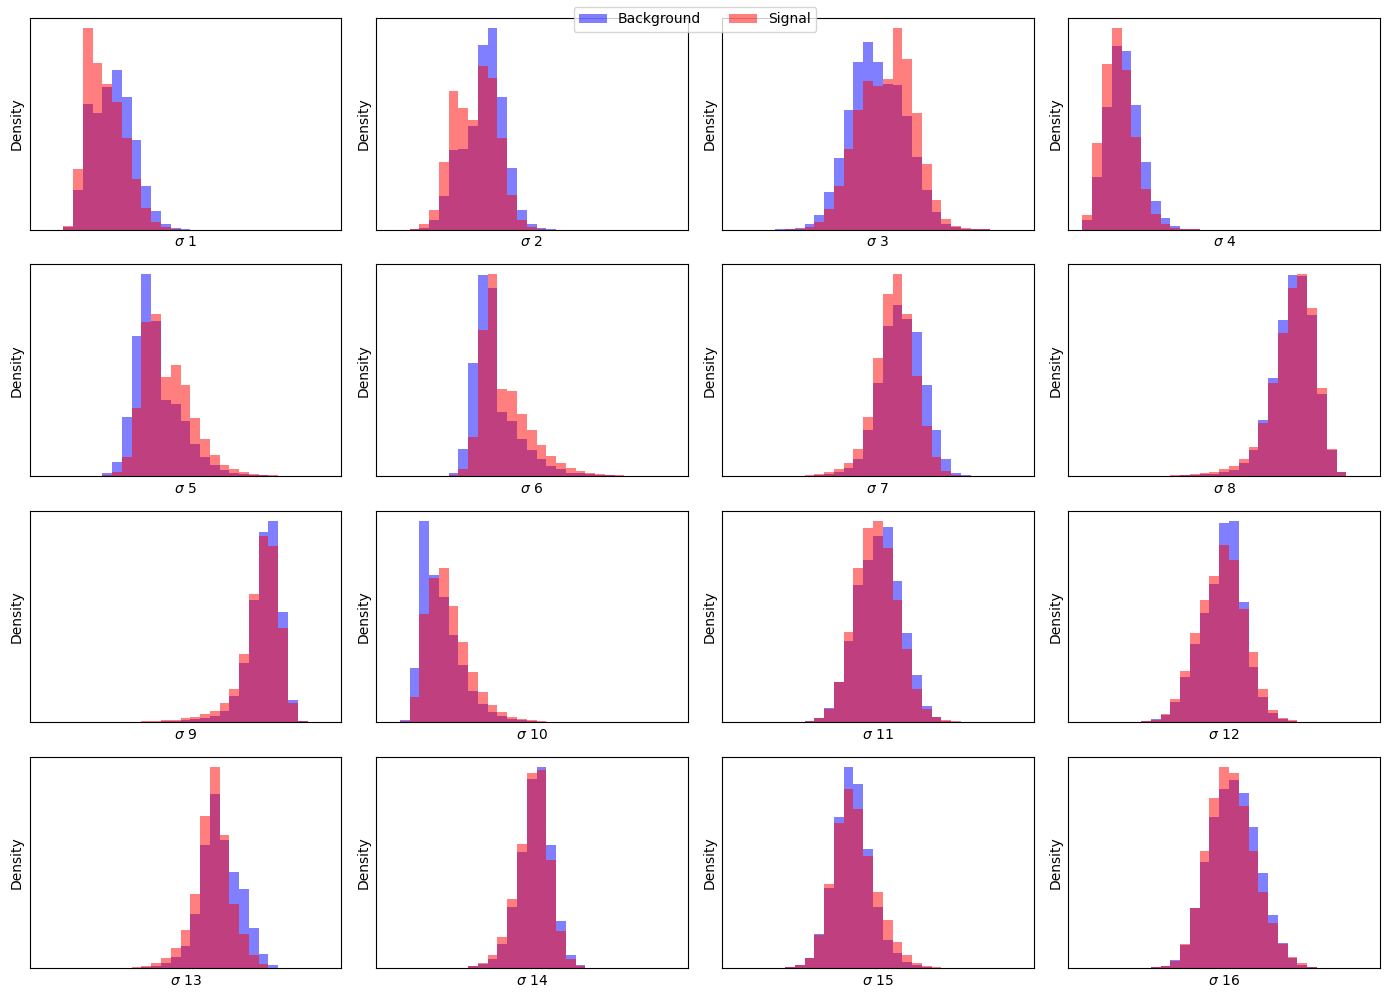

In [9]:
from src.plotting.evaluation import plot_latent_variable_distributions
plot_latent_variable_distributions(bg_mu.detach().numpy(), sig_mu.detach().numpy())